# 07 — IC50 Calculation

Fits a 4-parameter logistic (4PL) curve to each compound's dose-response data
and calculates IC50, Hill slope, and R².

Uses the same 4PL methodology as the [4-PL-Curve-fit-in-Python repo](https://github.com/sraashi/4-PL-Curve-fit-in-Python---numpy-and-scipy).

**Requires:** `data/results/dose_response_data.csv` (run `06_dose_response_setup.ipynb` first)

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

dr_df = pd.read_csv('data/results/dose_response_data.csv')
compounds = dr_df['Compound_ID'].unique()
print(f'Compounds to fit: {len(compounds)}')

Compounds to fit: 20


## 4PL Curve Fitting

$$f(x) = A + \frac{D - A}{1 + \left(\frac{C}{x}\right)^B}$$

- **A** = Bottom asymptote  
- **B** = Hill slope  
- **C** = IC50 (µM)  
- **D** = Top asymptote

In [2]:
def four_param_logistic(x, A, B, C, D):
    """4PL equation — ascending form for % inhibition assays."""
    return A + (D - A) / (1.0 + (C / x) ** B)

def fit_4pl(conc, inh):
    """Fit 4PL and return parameters + R²."""
    p0     = [min(inh), 1.0, np.median(conc), max(inh)]
    bounds = ([-np.inf, 0.1, 1e-6, -np.inf], [np.inf, 5.0, 1e6, np.inf])
    popt, _ = curve_fit(four_param_logistic, conc, inh, p0=p0,
                         bounds=bounds, maxfev=10000)
    y_pred = four_param_logistic(np.array(conc), *popt)
    ss_res = np.sum((np.array(inh) - y_pred) ** 2)
    ss_tot = np.sum((np.array(inh) - np.mean(inh)) ** 2)
    r2 = 1 - ss_res / ss_tot
    return popt, round(r2, 4)

## Fit all compounds

In [3]:
results = []

for cmpd in compounds:
    cdf  = dr_df[dr_df['Compound_ID'] == cmpd].sort_values('Concentration_uM')
    conc = cdf['Concentration_uM'].values
    inh  = cdf['Inhibition_pct'].values
    true_ic50 = cdf['True_IC50_uM'].iloc[0]
    max_measured = inh.max()

    try:
        (A, B, C, D), r2 = fit_4pl(conc, inh)
        # Flag IC50 as unreliable if max measured inhibition never exceeded 80% absolute
        incomplete_curve = max_measured < 80.0
        ic50_numeric = round(C, 3)
        ic50_reported = f'>{ic50_numeric}' if incomplete_curve else ic50_numeric
        results.append({
            'Compound_ID':    cmpd,
            'IC50_uM':        ic50_reported,
            'IC50_numeric':   ic50_numeric,
            'Hill_Slope':     round(B, 3),
            'Bottom_pct':     round(A, 2),
            'Top_pct':        round(D, 2),
            'Max_Measured_pct': round(max_measured, 2),
            'R2':             r2,
            'True_IC50_uM':   true_ic50,
            'Incomplete_Curve': incomplete_curve,
            'Status':         'OK'
        })
    except Exception as e:
        results.append({'Compound_ID': cmpd, 'Status': f'FAILED: {e}'})

ic50_df = pd.DataFrame(results)
print(ic50_df[['Compound_ID','IC50_uM','Max_Measured_pct','Top_pct','R2','Incomplete_Curve']].to_string(index=False))

Compound_ID IC50_uM  Max_Measured_pct  Top_pct     R2  Incomplete_Curve
    Cmpd_01   6.863             94.13    94.22 0.9997             False
    Cmpd_02    6.39             87.86    90.92 0.9973             False
    Cmpd_03 >11.977             76.99    92.46 0.9963              True
    Cmpd_04   6.531             90.05    90.99 0.9987             False
    Cmpd_05   5.243             94.79    95.87 0.9994             False
    Cmpd_06   6.762             85.89    92.95 0.9983             False
    Cmpd_07  15.306             87.16    91.06 0.9973             False
    Cmpd_08   5.099             86.44    94.90 0.9994             False
    Cmpd_09   4.989             96.74    98.86 0.9996             False
    Cmpd_10   9.499             93.53    97.65 0.9981             False
    Cmpd_11  22.408             85.37   102.67 0.9930             False
    Cmpd_12   0.864             87.91    86.95 0.9975             False
    Cmpd_13   18.25             92.43    94.93 0.9984           

## Dose-response trellis plot

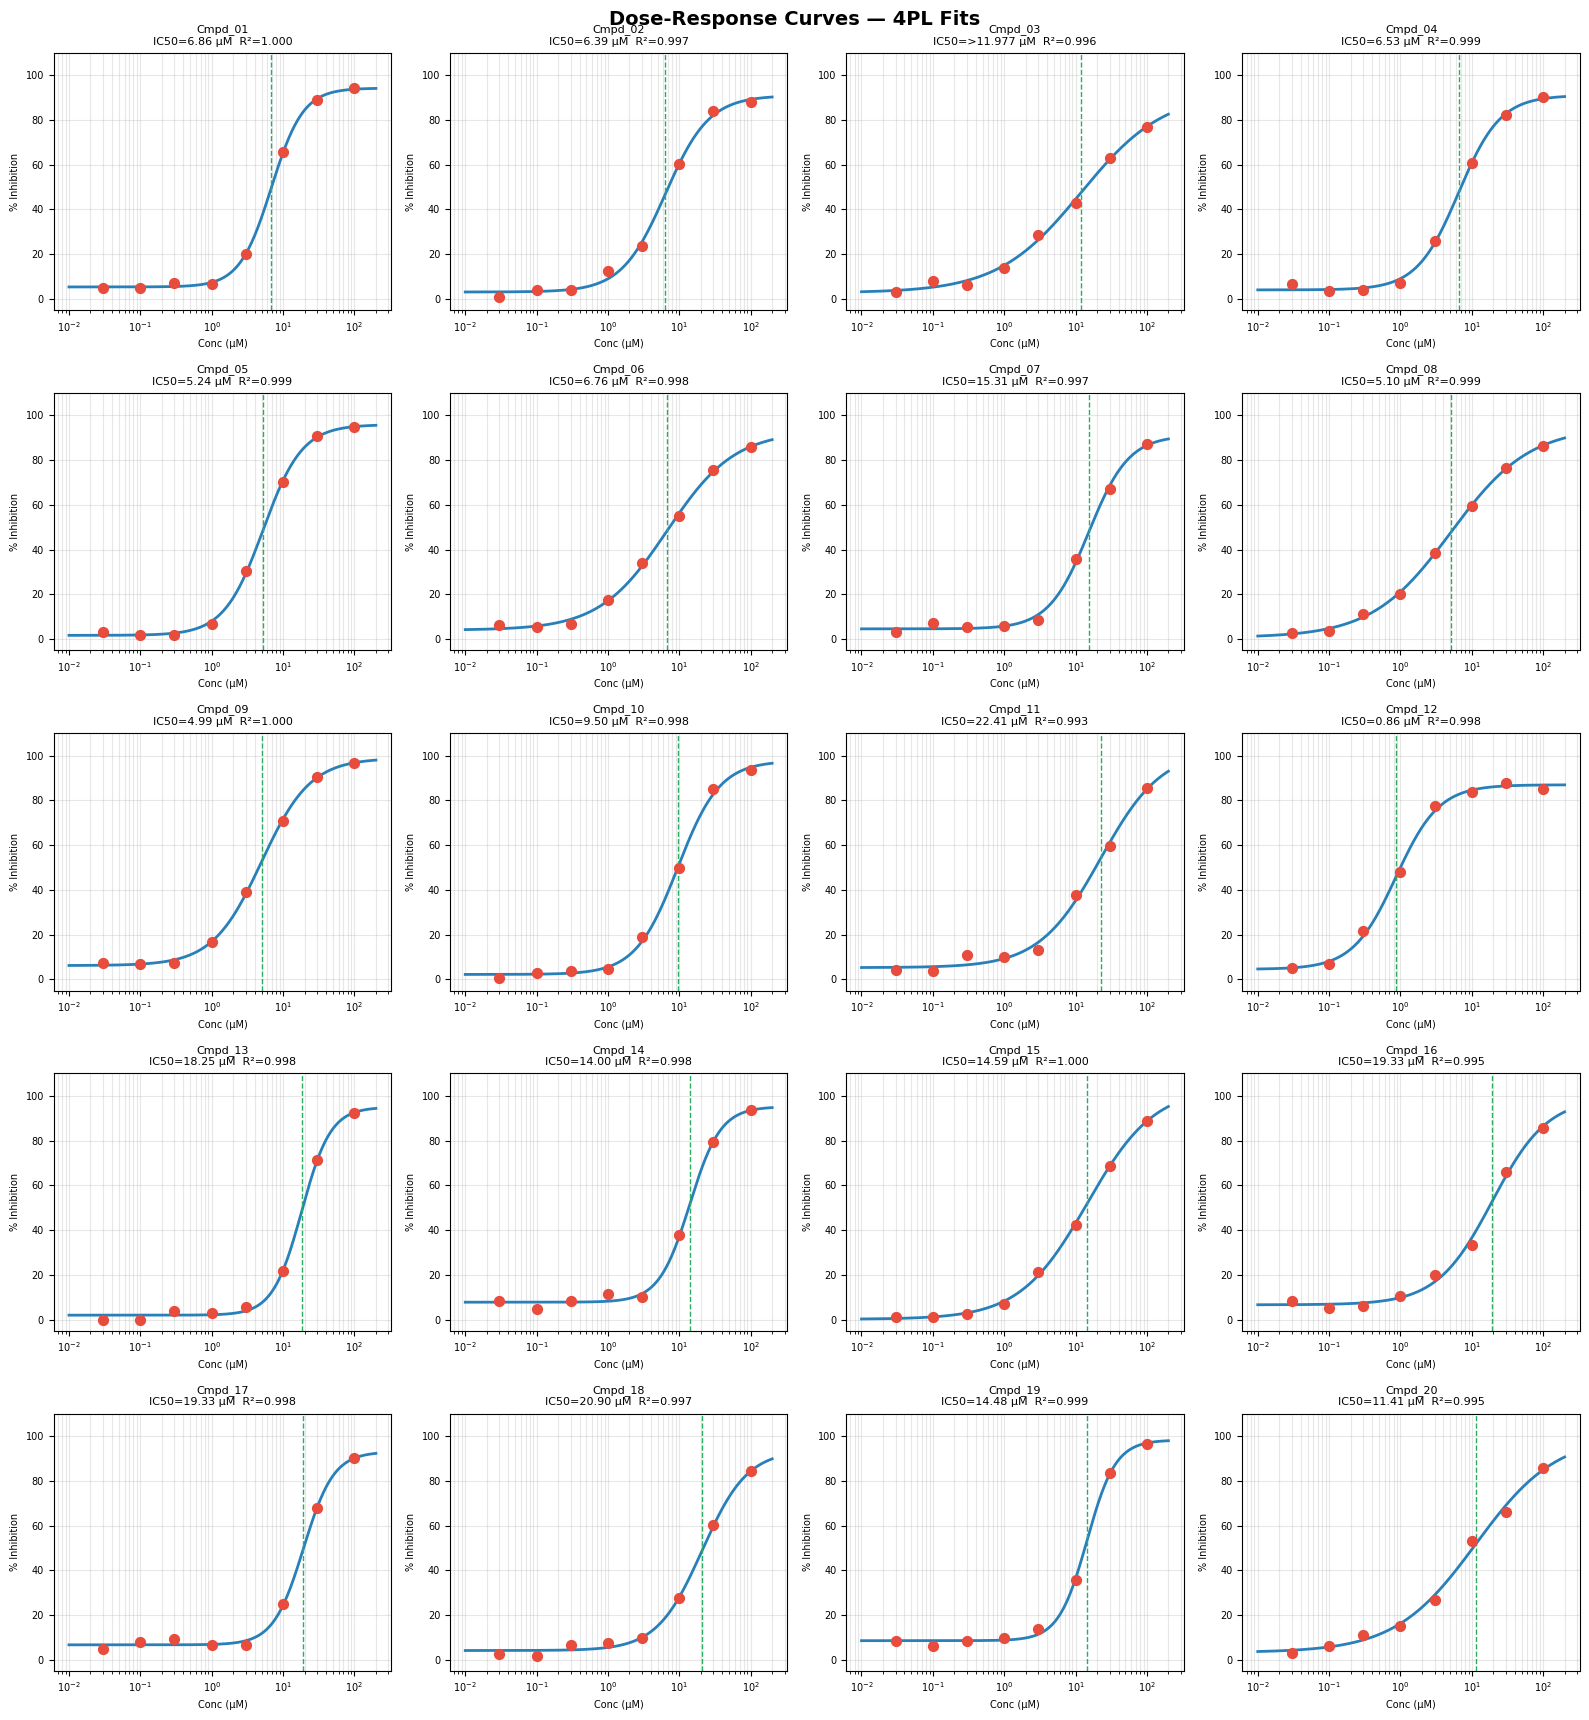

Saved: data/results/ic50_curves.png


In [4]:
n = len(compounds)
ncols = 4
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.5))
fig.suptitle('Dose-Response Curves — 4PL Fits', fontsize=14, fontweight='bold')
axes = axes.flatten()

x_smooth = np.logspace(np.log10(0.01), np.log10(200), 300)

for i, cmpd in enumerate(compounds):
    ax = axes[i]
    cdf  = dr_df[dr_df['Compound_ID'] == cmpd].sort_values('Concentration_uM')
    conc = cdf['Concentration_uM'].values
    inh  = cdf['Inhibition_pct'].values
    row  = ic50_df[ic50_df['Compound_ID'] == cmpd].iloc[0]

    ax.scatter(conc, inh, color='#e74c3c', s=50, zorder=5)

    if row['Status'] == 'OK':
        y_fit = four_param_logistic(x_smooth, row['Bottom_pct'], row['Hill_Slope'],
                                    row['IC50_numeric'], row['Top_pct'])
        ax.plot(x_smooth, y_fit, color='#2980b9', linewidth=2)
        ax.axvline(row['IC50_numeric'], color='#27ae60', linestyle='--', linewidth=1)
        ic50_label = row['IC50_uM'] if isinstance(row['IC50_uM'], str) else f"{row['IC50_uM']:.2f}"
        ax.set_title(f"{cmpd}\nIC50={ic50_label} µM  R²={row['R2']:.3f}",
                     fontsize=8)
    else:
        ax.set_title(f"{cmpd}\nFIT FAILED", fontsize=8, color='red')

    ax.set_xscale('log')
    ax.set_ylim(-5, 110)
    ax.set_xlabel('Conc (µM)', fontsize=7)
    ax.set_ylabel('% Inhibition', fontsize=7)
    ax.tick_params(labelsize=7)
    ax.grid(True, which='both', alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('data/results/ic50_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/results/ic50_curves.png')

## Save IC50 results

In [5]:
ic50_df.to_csv('data/results/ic50_results.csv', index=False)
ok = ic50_df[ic50_df['Status'] == 'OK']
flagged = ok[ok['Incomplete_Curve'] == True]
reliable = ok[ok['Incomplete_Curve'] == False]
print(f'Saved: data/results/ic50_results.csv')
print(f'Successfully fitted: {len(ok)}/{len(compounds)} compounds')
print(f'Flagged (incomplete curve, IC50 prefixed with >): {len(flagged)}')
print(f'\nFlagged compounds:')
print(flagged[['Compound_ID','IC50_uM','Max_Measured_pct','Top_pct']].to_string(index=False))
ic50_numeric = reliable['IC50_uM'].astype(float)
print(f'\nReliable IC50s only:')
print(f'Median IC50: {ic50_numeric.median():.2f} µM')
print(f'IC50 range:  {ic50_numeric.min():.3f} – {ic50_numeric.max():.3f} µM')

Saved: data/results/ic50_results.csv
Successfully fitted: 20/20 compounds
Flagged (incomplete curve, IC50 prefixed with >): 1

Flagged compounds:
Compound_ID IC50_uM  Max_Measured_pct  Top_pct
    Cmpd_03 >11.977             76.99    92.46

Reliable IC50s only:
Median IC50: 11.41 µM
IC50 range:  0.864 – 22.408 µM
